# Predicting Student Health Risk (Playground Series S6E7)

## One-time setup (before downloading data)

1. **Join the competition** on Kaggle and accept the rules:  
   https://www.kaggle.com/competitions/playground-series-s6e7
2. **Create an API token**: go to https://www.kaggle.com/settings/api → **Generate New Token**
3. Run the **Login** cell below and paste your token when prompted, then click **Login**

> Competition downloads require authentication so Kaggle can verify you joined the competition.


In [142]:
import kagglehub

# Run once per session (shows a login widget in the notebook).
# Paste your API token from https://www.kaggle.com/settings/api and click Login.
kagglehub.login()



In [143]:
# Download competition data to ./data (after successful login above)
path = kagglehub.competition_download(
    "playground-series-s6e7",
    output_dir="./data",
)

print("Path to competition files:", path)

Path to competition files: ./data


# Libraries

In [144]:
import numpy as np

import numpy as np


import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

In [145]:
train_df = pd.read_csv("data/train.csv")
test_df = pd.read_csv("data/test.csv")

train_df.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [146]:
sample_submission = pd.read_csv("data/sample_submission.csv")
sample_submission.head()

,id,health_condition
0,690088,at-risk
1,690089,at-risk
2,690090,at-risk
3,690091,at-risk
4,690092,at-risk


In [147]:
print("Train dataset shape:", train_df.shape)
print("Test dataset shape:", test_df.shape)

Train dataset shape: (690088, 15)
Test dataset shape: (295753, 14)


In [148]:
train_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  str    
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  str    
 10  stress_level             607277 non-null  str    
 11  sleep_quality            631757 non-null  str    
 12  physical_activity_level  653467 non-null  str    
 13  smoking_alcohol          661506 non-null  str    
 14  gender         

In [149]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 295753 entries, 0 to 295752
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       295753 non-null  int64  
 1   sleep_duration           263182 non-null  float64
 2   heart_rate               292396 non-null  float64
 3   bmi                      289797 non-null  float64
 4   calorie_expenditure      273101 non-null  float64
 5   step_count               289789 non-null  float64
 6   exercise_duration        292795 non-null  float64
 7   water_intake             277120 non-null  float64
 8   diet_type                292795 non-null  str    
 9   stress_level             260263 non-null  str    
 10  sleep_quality            270754 non-null  str    
 11  physical_activity_level  280058 non-null  str    
 12  smoking_alcohol          283504 non-null  str    
 13  gender                   286593 non-null  str    
dtypes: float64(7), 

## EDA for Train and Test data

In [150]:
test_df.isna().sum()

id                             0
sleep_duration             32571
heart_rate                  3357
bmi                         5956
calorie_expenditure        22652
step_count                  5964
exercise_duration           2958
water_intake               18633
diet_type                   2958
stress_level               35490
sleep_quality              24999
physical_activity_level    15695
smoking_alcohol            12249
gender                      9160
dtype: int64

In [151]:
test_df.duplicated().sum()

np.int64(0)

In [152]:
train_df.isna().sum()

id                             0
health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64

In [153]:
train_df.duplicated().sum()

np.int64(0)

In [154]:
# Remove leading and trailing spaces from all object (string) columns
train_df = train_df.apply(lambda col: col.str.strip() if col.dtype == "object" else col)

In [155]:
train_df.describe()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,690088.00000,614089.000000,682255.000000,676190.000000,637235.000000,676172.000000,683187.000000,646611.000000
mean,345043.50000,6.992597,75.096504,22.984925,2226.084931,8615.953050,38.751456,2.188542
std,199211.39062,1.215407,8.175106,2.481787,347.532098,3929.399831,14.742189,0.518489
min,0.00000,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000
25%,172521.75000,6.160000,69.400000,21.320000,2053.000000,5389.000000,29.200000,1.840000
50%,345043.50000,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000
75%,517565.25000,7.810000,80.700000,24.660000,2456.000000,12114.000000,49.400000,2.500000
max,690087.00000,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000


## Bar Charts for Each Feature

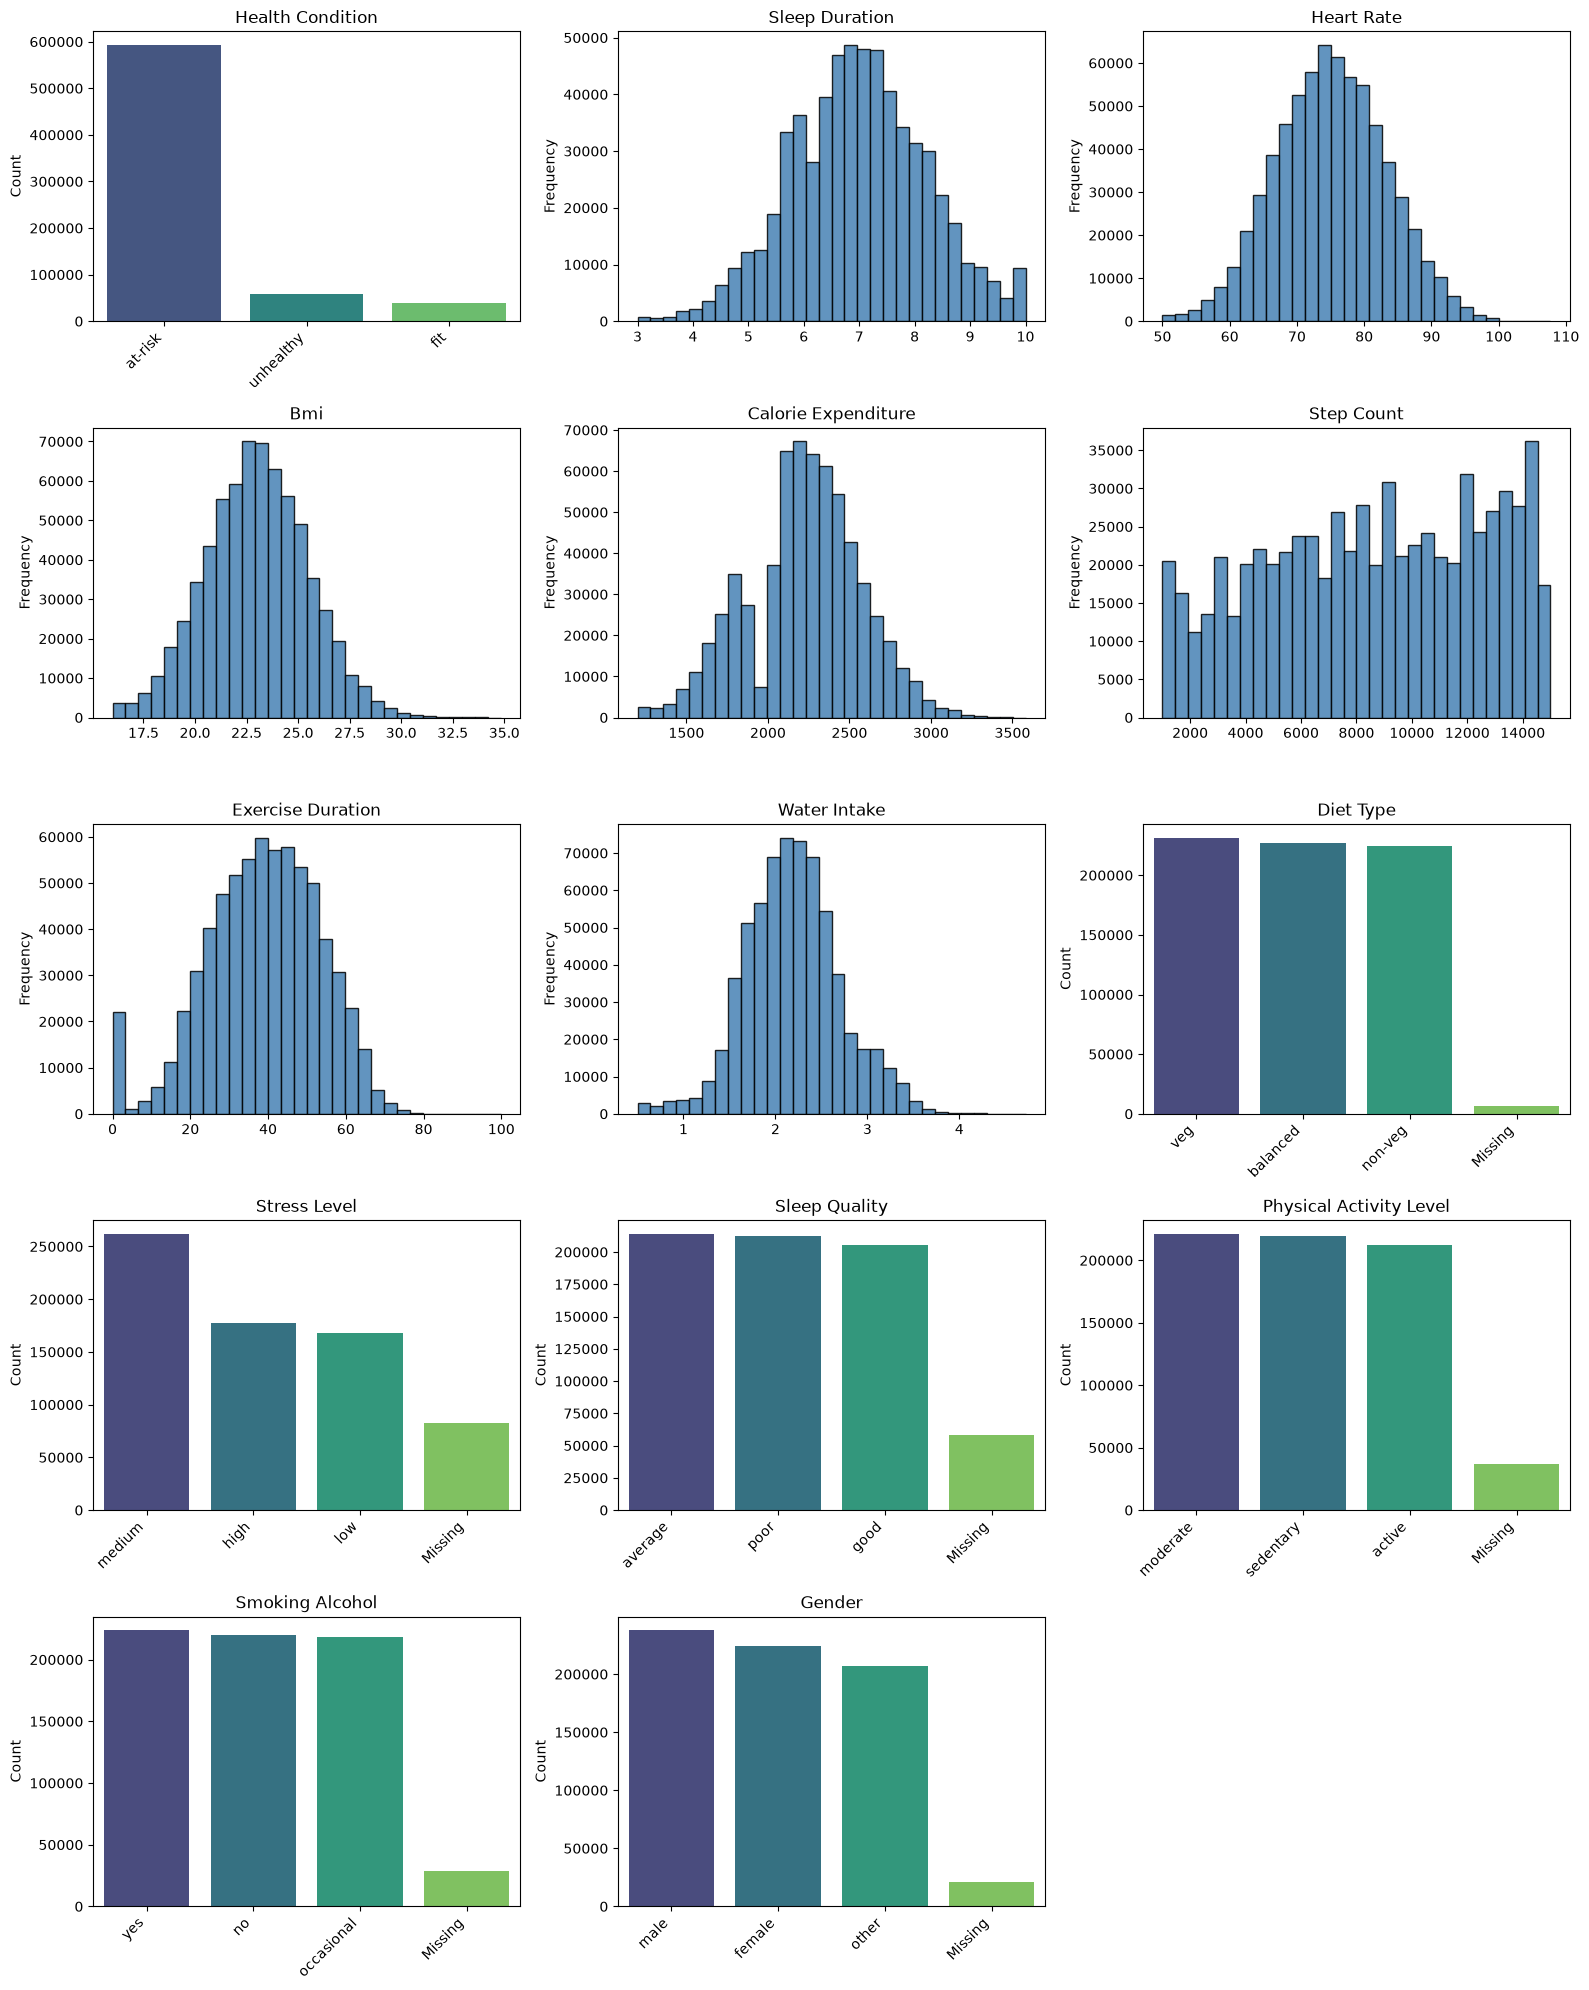

In [156]:
# Bar chart for every feature in the training data (excluding id)
feature_cols = [col for col in train_df.columns if col != "id"]
cat_cols = train_df[feature_cols].select_dtypes(include=["object", "string"]).columns.tolist()
num_cols = [col for col in feature_cols if col not in cat_cols]

n_features = len(feature_cols)
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = np.array(axes).flatten()

for ax, col in zip(axes, feature_cols):
    if col in cat_cols:
        counts = train_df[col].fillna("Missing").astype(str).value_counts()
        sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="viridis", hue=counts.index, legend=False)
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=45)
        for label in ax.get_xticklabels():
            label.set_horizontalalignment("right")
    else:
        data = train_df[col].dropna()
        ax.hist(data, bins=30, color="steelblue", edgecolor="black", alpha=0.85)
        ax.set_ylabel("Frequency")

    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("")

for ax in axes[n_features:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

# Fill missing values

In [157]:
train_df["sleep_duration"] = train_df["sleep_duration"].fillna(train_df["sleep_duration"].mean())
test_df["sleep_duration"] = test_df["sleep_duration"].fillna(train_df["sleep_duration"].mean())

train_df["heart_rate"] = train_df["heart_rate"].fillna(train_df["heart_rate"].mean())
test_df["heart_rate"] = test_df["heart_rate"].fillna(train_df["heart_rate"].mean())

train_df["bmi"] = train_df["bmi"].fillna(train_df["bmi"].mean())
test_df["bmi"] = test_df["bmi"].fillna(train_df["bmi"].mean())

train_df["calorie_expenditure"] = train_df["calorie_expenditure"].fillna(train_df["calorie_expenditure"].mean())
test_df["calorie_expenditure"] = test_df["calorie_expenditure"].fillna(train_df["calorie_expenditure"].mean())

train_df["step_count"] = train_df["step_count"].fillna(
    train_df["step_count"].median()
)

test_df["step_count"] = test_df["step_count"].fillna(
    train_df["step_count"].median()
)

# Simple Mean Imputation
train_df["exercise_duration"] = train_df["exercise_duration"].fillna(
    train_df["exercise_duration"].mean()
)
# Simple Mean Imputation
test_df["exercise_duration"] = test_df["exercise_duration"].fillna(
    train_df["exercise_duration"].mean()
)

# Fill missing water_intake values with the mean
train_df["water_intake"] = train_df["water_intake"].fillna(
    train_df["water_intake"].mean()
)
# Fill missing water_intake values with the mean
test_df["water_intake"] = test_df["water_intake"].fillna(
    train_df["water_intake"].mean()
)


In [158]:
mode_diet = train_df["diet_type"].mode()[0]
train_df["diet_type"] = train_df["diet_type"].fillna(mode_diet)

mode_stress = train_df["stress_level"].mode()[0]
train_df["stress_level"] = train_df["stress_level"].fillna(mode_stress)

mode_sleep = train_df["sleep_quality"].mode()[0]
train_df["sleep_quality"] = train_df["sleep_quality"].fillna(mode_sleep)

mode_pal = train_df["physical_activity_level"].mode()[0]
train_df["physical_activity_level"] = train_df["physical_activity_level"].fillna(mode_pal)

mode_sa = train_df["smoking_alcohol"].mode()[0]
train_df["smoking_alcohol"] = train_df["smoking_alcohol"].fillna(mode_sa)

mode_gender = train_df["gender"].mode()[0]
train_df["gender"] = train_df["gender"].fillna(mode_gender)





In [159]:
cols = [
    "diet_type",
    "stress_level",
    "sleep_quality",
    "physical_activity_level",
    "smoking_alcohol",
    "gender"
]

for col in cols:
    mode_value = train_df[col].mode()[0]
    
    # Fill test data using train mode
    test_df[col] = test_df[col].fillna(mode_value)

In [160]:
train_df.isna().sum()

id                         0
health_condition           0
sleep_duration             0
heart_rate                 0
bmi                        0
calorie_expenditure        0
step_count                 0
exercise_duration          0
water_intake               0
diet_type                  0
stress_level               0
sleep_quality              0
physical_activity_level    0
smoking_alcohol            0
gender                     0
dtype: int64

In [161]:
test_df.isna().sum()

id                         0
sleep_duration             0
heart_rate                 0
bmi                        0
calorie_expenditure        0
step_count                 0
exercise_duration          0
water_intake               0
diet_type                  0
stress_level               0
sleep_quality              0
physical_activity_level    0
smoking_alcohol            0
gender                     0
dtype: int64

In [162]:
# Get string/object columns
string_cols = train_df.select_dtypes(include=['object']).columns

print(string_cols)

Index(['health_condition', 'diet_type', 'stress_level', 'sleep_quality',
       'physical_activity_level', 'smoking_alcohol', 'gender'],
      dtype='str')


C:\Users\Mithun\AppData\Local\Temp\ipykernel_19696\2167376741.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols = train_df.select_dtypes(include=['object']).columns


In [163]:
train_df.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,medium,average,sedentary,yes,male


In [164]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  str    
 2   sleep_duration           690088 non-null  float64
 3   heart_rate               690088 non-null  float64
 4   bmi                      690088 non-null  float64
 5   calorie_expenditure      690088 non-null  float64
 6   step_count               690088 non-null  float64
 7   exercise_duration        690088 non-null  float64
 8   water_intake             690088 non-null  float64
 9   diet_type                690088 non-null  str    
 10  stress_level             690088 non-null  str    
 11  sleep_quality            690088 non-null  str    
 12  physical_activity_level  690088 non-null  str    
 13  smoking_alcohol          690088 non-null  str    
 14  gender         

In [165]:
train_df["health_condition"].unique()

<StringArray>
['unhealthy', 'at-risk', 'fit']
Length: 3, dtype: str

In [166]:
categorical_cols = train_df.select_dtypes(include=["object"]).columns

unique_df = pd.DataFrame({
    "Column": categorical_cols,
    "Unique Values": [train_df[col].unique().tolist() for col in categorical_cols]
})

display(unique_df)

C:\Users\Mithun\AppData\Local\Temp\ipykernel_19696\1044986624.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train_df.select_dtypes(include=["object"]).columns


,Column,Unique Values
0,health_condition,"[unhealthy, at-risk, fit]"
1,diet_type,"[veg, non-veg, balanced]"
2,stress_level,"[high, low, medium]"
3,sleep_quality,"[average, poor, good]"
4,physical_activity_level,"[sedentary, moderate, active]"
5,smoking_alcohol,"[yes, occasional, no]"
6,gender,"[female, other, male]"


In [167]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

In [168]:
train = train_df.copy()
test = test_df.copy()

In [169]:
le = LabelEncoder()

y_train = le.fit_transform(train["health_condition"])

# Check the mapping
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'at-risk': np.int64(0), 'fit': np.int64(1), 'unhealthy': np.int64(2)}


In [170]:
X_train = train.drop(columns=["id", "health_condition"])
X_test = test.drop(columns=["id"])

In [171]:
ordinal_cols = [
    "stress_level",
    "sleep_quality",
    "physical_activity_level",
    "smoking_alcohol"
]

ordinal_encoder = OrdinalEncoder(categories=[
    ["low", "medium", "high"],
    ["poor", "average", "good"],
    ["sedentary", "moderate", "active"],
    ["no", "occasional", "yes"]
])

X_train[ordinal_cols] = ordinal_encoder.fit_transform(X_train[ordinal_cols])
X_test[ordinal_cols] = ordinal_encoder.transform(X_test[ordinal_cols])

In [172]:
X_train = pd.get_dummies(
    X_train,
    columns=["diet_type", "gender"],
    dtype=int
)

X_test = pd.get_dummies(
    X_test,
    columns=["diet_type", "gender"],
    dtype=int
)

In [173]:
print(X_train.shape)
print(X_test.shape)

(690088, 17)
(295753, 17)


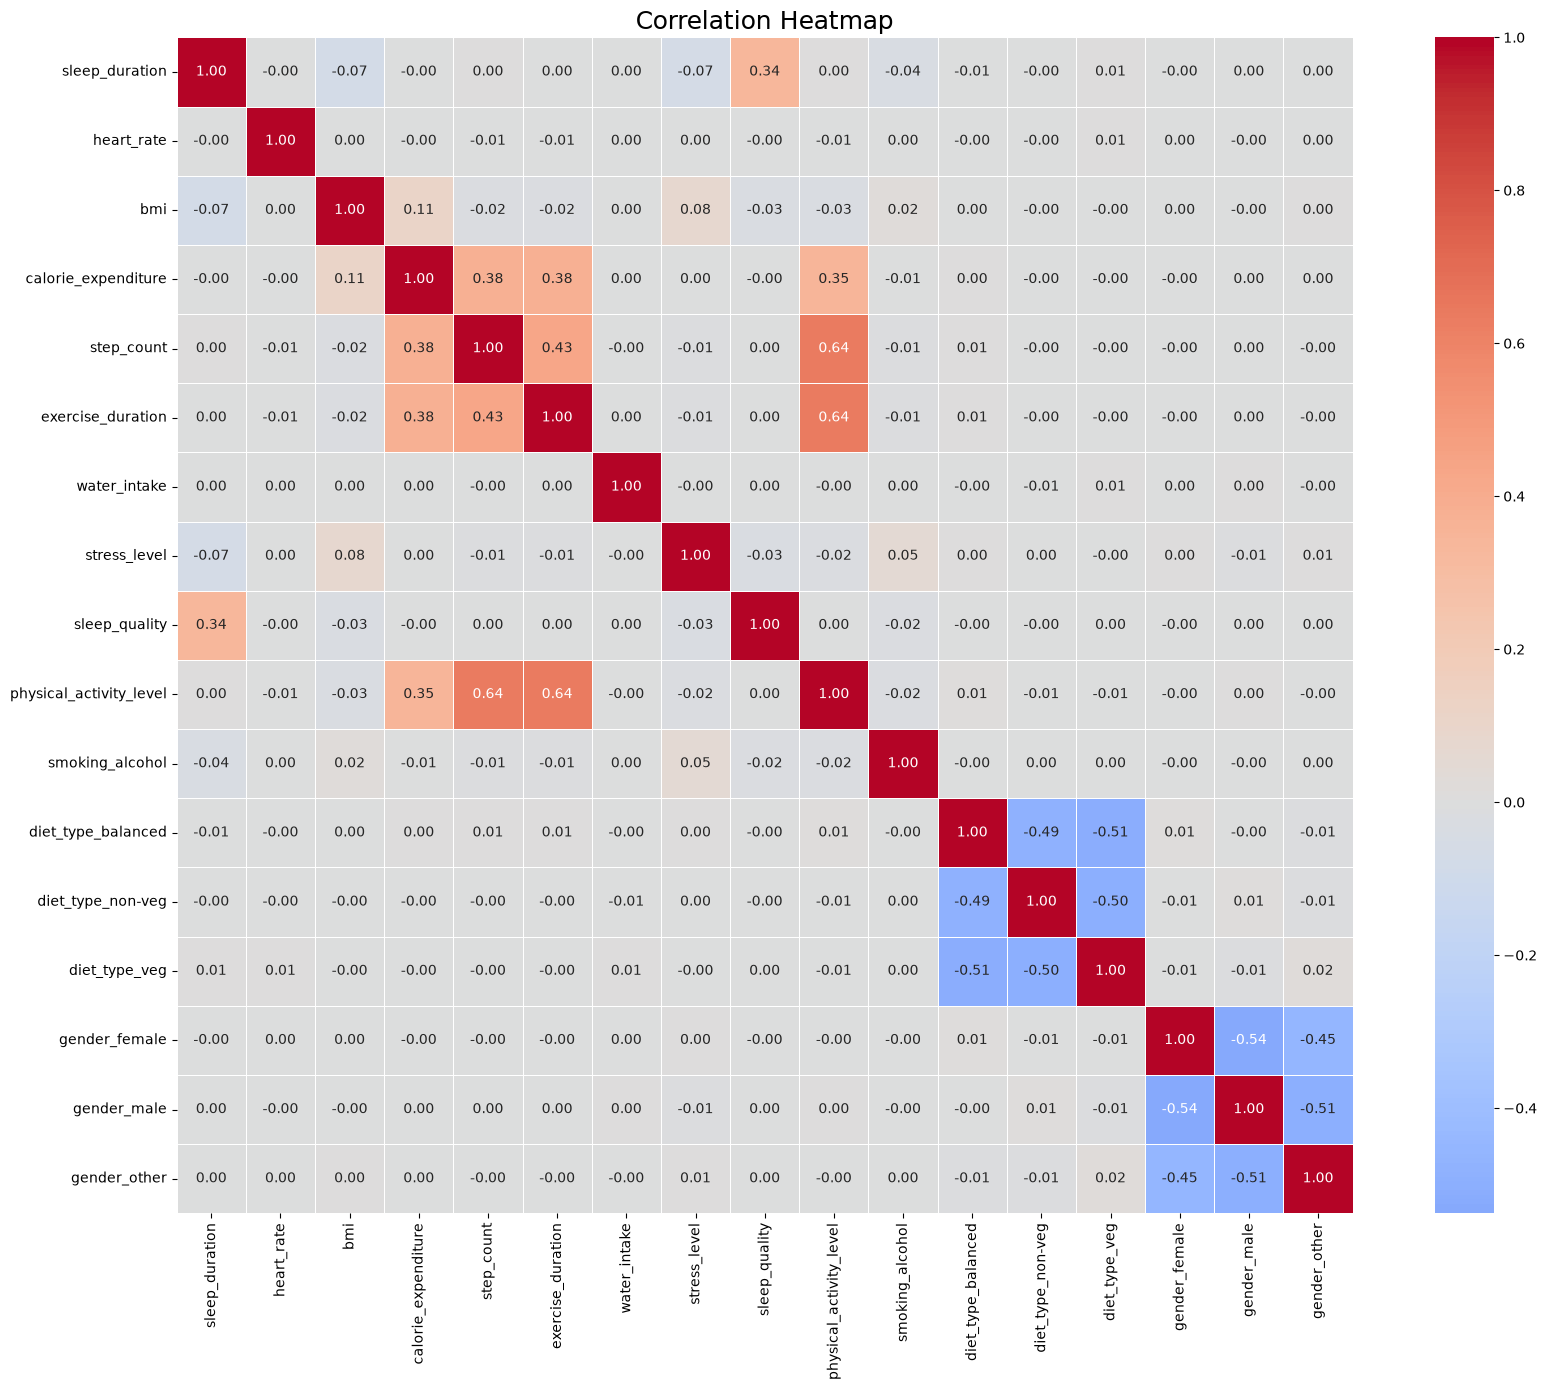

In [174]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation matrix
corr_matrix = X_train.corr()

# Plot heatmap
plt.figure(figsize=(18, 14))

sns.heatmap(
    corr_matrix,
    annot=True,          # Show correlation values
    fmt=".2f",           # Display 2 decimal places
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    cbar=True
)

plt.title("Correlation Heatmap", fontsize=18)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

In [175]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

In [176]:
X_train_scaled

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,diet_type_balanced,diet_type_non-veg,diet_type_veg,gender_female,gender_male,gender_other
0,-1.546057,-0.553173,1.088904,-0.155962,-1.875402,-1.292002,-0.654609,1.393094,0.012149,-1.250303,1.153919,-0.699877,-0.695238,1.376764,1.442404,-0.775425,-0.654465
1,-1.275675,-0.467057,1.162174,-0.778795,0.326554,0.760044,-1.850089,-1.434236,0.012149,0.013075,1.153919,-0.699877,1.438357,-0.726341,-0.693287,-0.775425,1.527965
2,-1.485003,0.037337,0.633002,1.383152,1.438459,-0.044413,-1.172651,1.393094,-1.273124,1.276454,1.153919,-0.699877,-0.695238,1.376764,-0.693287,1.289615,-0.654465
3,-1.999600,0.258778,0.059054,1.209478,-0.371953,1.441787,-0.335815,1.393094,0.012149,1.276454,-0.057069,-0.699877,-0.695238,1.376764,1.442404,-0.775425,-0.654465
4,0.207062,-0.208709,2.220519,0.999871,-0.523635,0.494165,0.122453,-0.020571,0.012149,-1.250303,1.153919,-0.699877,-0.695238,1.376764,-0.693287,1.289615,-0.654465
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690083,-0.595360,-0.663893,0.457968,-0.206867,0.060469,-0.542085,1.616803,1.393094,-1.273124,1.276454,1.153919,-0.699877,1.438357,-0.726341,1.442404,-0.775425,-0.654465
690084,-1.057625,-2.595352,1.373843,1.892198,-0.548315,0.930480,-1.451596,-0.020571,0.012149,0.013075,-1.268057,-0.699877,-0.695238,1.376764,-0.693287,1.289615,-0.654465
690085,0.564664,1.304472,-0.437554,-0.093080,0.159447,0.173745,-1.232425,-0.020571,0.012149,1.276454,-1.268057,-0.699877,1.438357,-0.726341,-0.693287,1.289615,-0.654465
690086,-0.220315,-0.257918,-1.731991,-0.494328,1.219934,1.216812,0.819816,-0.020571,0.012149,1.276454,1.153919,1.428823,-0.695238,-0.726341,-0.693287,1.289615,-0.654465


In [177]:
!pip install xgboost


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: C:\Users\Mithun\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [178]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

In [179]:
xgb = XGBClassifier(
    objective="multi:softmax",
    num_class=3,
    random_state=42,
    eval_metric="mlogloss"
)

In [180]:
param_dist = {
    "n_estimators": randint(100, 500),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.29),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_weight": randint(1, 10),
    "gamma": uniform(0, 5)
}

In [181]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,
    scoring="balanced_accuracy",
    cv=5,
    random_state=42,
    verbose=2,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier..._class=3, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': <scipy.stats....002B5DAE88F50>, 'gamma': <scipy.stats....002B5CCD0A030>, 'learning_rate': <scipy.stats....002B5E1659650>, 'max_depth': <scipy.stats....002B600E2A9C0>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score

In [187]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Balanced Accuracy:")
print(random_search.best_score_)

Best Parameters:
{'colsample_bytree': np.float64(0.836965827544817), 'gamma': np.float64(0.23225206359998862), 'learning_rate': np.float64(0.1861880070514171), 'max_depth': 7, 'min_child_weight': 9, 'n_estimators': 266, 'subsample': np.float64(0.6053059844639466)}

Best Balanced Accuracy:
0.8587213938707781


In [188]:
best_xgb = random_search.best_estimator_
print(best_xgb)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=np.float64(0.836965827544817), device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric='mlogloss', feature_types=None, feature_weights=None,
              gamma=np.float64(0.23225206359998862), grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=np.float64(0.1861880070514171), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=9, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=266, n_jobs=None, num_class=3, ...)


In [189]:
test_predictions = best_xgb.predict(X_test)

In [190]:
le = LabelEncoder()
y_train = le.fit_transform(train["health_condition"])

In [191]:
test_predictions = le.inverse_transform(test_predictions)

In [192]:
submission = pd.DataFrame({
    "id": test_df["id"],
    "health_condition": test_predictions
})

submission.to_csv("submission.csv", index=False)